In [1]:
import pickle
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, classification_report


In [2]:
model_ver = [
    "lgb_model.txt", "model_pipeline_v1.txt",
    "model_pipeline_v2_f199.txt", "model_pipeline_v2_f92.txt",
    "model_pipeline_v2_f298.txt"
]
# pipeline = lgb.Booster(model_file=model_ver[4])
pipeline = XGBClassifier()
pipeline.load_model("model_pipeline_v2_f298.json")
pipeline


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",[0.33924365]
,booster,'gbtree'
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,"['float', 'int', ...]"


In [3]:
with open("training_metrics.pkl", "rb") as f:
    training_metrics = pickle.load(f)

type(training_metrics), training_metrics.keys()

(dict,
 dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'val_preds', 'raw_probs']))

In [4]:
sum(training_metrics["val_preds"] == training_metrics['y_val'].to_numpy()) / len(training_metrics["val_preds"])

np.float64(0.87325)

In [7]:
X, y = train_df.drop("liquidity_stress_next_30d", axis=1), train_df["liquidity_stress_next_30d"]
X_, _ = feature_pipeline.transform(X, is_train=True)
X_.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 298 entries, arpu to earning_pattern_Weekly Earner
dtypes: bool(12), float64(243), int64(43)
memory usage: 87.7 MB


In [8]:
# In-notebook predictions
raw_y_pred = pipeline.predict_proba(X_)[:, 1]

In [9]:
(raw_y_pred > 0.5).astype(int)

array([1, 0, 1, ..., 0, 0, 0], shape=(40000,))

Classification Report:                precision    recall  f1-score   support

           0       0.97      0.95      0.96     34000
           1       0.76      0.83      0.79      6000

    accuracy                           0.93     40000
   macro avg       0.86      0.89      0.88     40000
weighted avg       0.94      0.93      0.94     40000



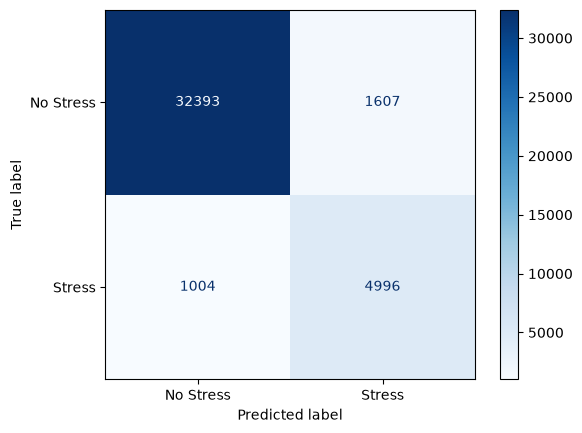

In [10]:
print("Classification Report: ", classification_report(y.to_numpy(), (raw_y_pred >= 0.5).astype(int)))
cm = confusion_matrix(y.to_numpy(), (raw_y_pred >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["No Stress", "Stress"]
)
disp.plot(cmap="Blues")
plt.show()


In [11]:
from sklearn.metrics import log_loss
log_loss(y.to_numpy(), raw_y_pred)

0.22534222900867462

In [12]:
roc_auc_score(y.to_numpy(), raw_y_pred)

0.9721215024509805

In [13]:
# Run prediction on training set
raw_train_y_pred = pipeline.predict(training_metrics["X_train"])
raw_train_y_pred


array([1, 0, 1, ..., 0, 0, 0], shape=(32000,))

In [14]:
training_metrics['y_train'].to_numpy()

array([1, 0, 1, ..., 0, 0, 0], shape=(32000,))

In [15]:
print(classification_report(training_metrics['y_train'].to_numpy(), (raw_train_y_pred> 0.5).astype(int)))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     27200
           1       0.76      0.83      0.79      4800

    accuracy                           0.94     32000
   macro avg       0.86      0.89      0.88     32000
weighted avg       0.94      0.94      0.94     32000



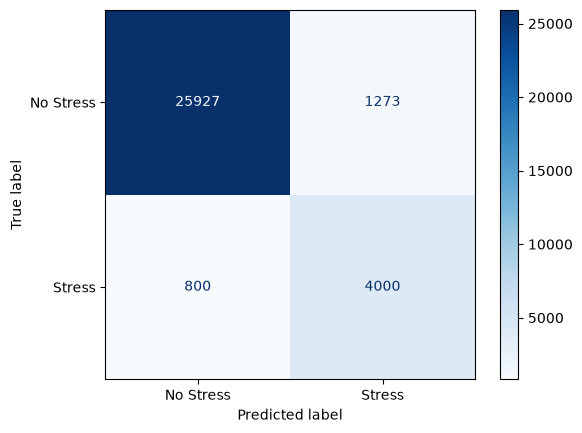

In [16]:
# Change y_pred to int
y_pred = (raw_train_y_pred > 0.5).astype(int)
cm = confusion_matrix(training_metrics["y_train"], y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["No Stress", "Stress"]
)
disp.plot(cmap="Blues")
plt.show()

In [17]:
from sklearn.metrics import log_loss
log_loss(training_metrics['y_train'].to_numpy(), raw_train_y_pred)

2.3349529211137456

In [ ]:
log_loss(training_metrics["y_val"].to_numpy(), raw_y_pred)


In [19]:
# # 2. Extract feature importances
# importance_df = pd.DataFrame(
#     {'feature': X_train.columns, 'importance': pipeline.feature_importances_}
# ).sort_values('importance', ascending=False)
# importance_df

# 1. Extract importance scores by explicitly choosing 'split' or 'gain'
importance_split = pipeline.feature_importance(importance_type='split')
importance_gain = pipeline.feature_importance(importance_type='gain')

# 2. Map to feature names
feat_importances = pd.DataFrame({
    'Feature': pipeline.feature_name(),
    'Split_Score': importance_split,
    'Gain_Score': importance_gain
}).sort_values(by='Gain_Score', ascending=False)

AttributeError: 'XGBClassifier' object has no attribute 'feature_importance'

In [19]:
feat_importances.head(20)

,Feature,Split_Score,Gain_Score
202,bal_slope_6m,359,58772.481350
201,net_coverage_recent_3m,84,30960.697725
204,inflow_slope_6m,177,21267.097714
173,m3_daily_avg_bal,207,12924.966213
174,m4_daily_avg_bal,289,12512.653450
199,inflow_drift_3m,42,8191.484826
180,m2_total_inflow,122,7509.366236
183,m3_total_inflow,126,6917.528437
172,m2_daily_avg_bal,181,6272.985643
161,m4_withdraw_highest_amount,80,5868.528626


In [20]:
# Measure the roc and classification report

print("ROC SCORE: ", roc_auc_score(training_metrics["y_train"], y_pred))
print("CLASSIFICATION REPORT:\n", classification_report(training_metrics["y_train"], y_pred))

ROC SCORE:  0.8932659313725492
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     27200
           1       0.76      0.83      0.79      4800

    accuracy                           0.94     32000
   macro avg       0.86      0.89      0.88     32000
weighted avg       0.94      0.94      0.94     32000



In [ ]:
del FeaturePipeline
del feature_pipeline

In [5]:
import pandas as pd
from build import FeaturePipeline

feature_pipeline = FeaturePipeline()

In [6]:
test_df = pd.read_csv("Test.csv")
train_df = pd.read_csv("Train.csv")

In [21]:
test_df = test_df.reindex(columns=train_df.drop("liquidity_stress_next_30d", axis=1).columns.tolist(), fill_value=0)
X_test, _ = feature_pipeline.transform(test_df, is_train=False)

X_test.info()
# X_train, y = feature_pipeline.transform(train_df)

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Columns: 298 entries, arpu to earning_pattern_Weekly Earner
dtypes: bool(12), float64(243), int64(43)
memory usage: 65.8 MB


In [22]:
X_train.select_dtypes(include=['float64', 'int64']).columns.to_list()

NameError: name 'X_train' is not defined

In [5]:
from build import ModelPipeline

# Initialize pipeline
pipeline = ModelPipeline(target_col="liquidity_stress_next_30d")

# Run automated split, feature extraction, model fitting, and validation evaluation
pipeline.fit_and_evaluate("Train.csv", val_size=0.2, threshold=0.5)

Reading dataset from: Train.csv
Dataset Split: Train = 32000 rows, Val = 8000 rows


/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["m1_cashout_intensity"] = data["m1_total_outflow"] / (


Features generated: 92 columns. Imbalance Ratio: 5.67
Fitting 2 folds for each of 216 candidates, totalling 432 fits


/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["m1_cashout_intensity"] = data["m1_total_outflow"] / (


Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 350, 'num_leaves': 31, 'scale_pos_weight': 4.25}
Best CV Score: 0.4608
--- Training CatBoost Classifier ---
--- Training Regularized Logistic Regression ---

[SUCCESS] All Models Fitted!

================ VALIDATION RESULTS ================
Validation ROC-AUC Score: 0.805368

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      6800
           1       0.37      0.62      0.47      1200

    accuracy                           0.79      8000
   macro avg       0.65      0.72      0.67      8000
weighted avg       0.84      0.79      0.81      8000



In [24]:
# Run prediction
test_probs = pipeline.predict_proba(X_test)[:, 1]
# submission = pd.DataFrame({"ID": test_df["ID"], "Target": test_probs})
test_probs

array([0.24916725, 0.20993829, 0.04077781, ..., 0.47331953, 0.01570977,
       0.553757  ], shape=(30000,), dtype=float32)

In [25]:
submission = pd.DataFrame({"ID": test_df["ID"], "Target": test_probs})
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.249167
1,ID_29975A9C7E,0.209938
2,ID_F59CE25650,0.040778
3,ID_E875F68D1A,0.015604
4,ID_2902B1C0D0,0.018629
